In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix

# Roll Number: 102303812
# a = 1, b = 2
a = 1
b = 2

# Dataset parameters
total_samples = 31
noise_level = 0.15
rotation_angle = np.deg2rad(30)

np.random.seed(1)

In [2]:
# Generate synthetic binary classification dataset
# Using linearly separable data with controlled noise

num_points = total_samples
class_zero = np.random.randn(num_points, 2) * 0.6 + np.array([-1.5, -1.5])
class_one = np.random.randn(num_points, 2) * 0.6 + np.array([1.5, 1.5])

# Add controlled noise to make it slightly more realistic
noise_vec_c0 = np.random.randn(num_points, 2) * noise_level
noise_vec_c1 = np.random.randn(num_points, 2) * noise_level

class_zero = class_zero + noise_vec_c0
class_one = class_one + noise_vec_c1

# Combine and create labels
X = np.vstack([class_zero, class_one])
y = np.hstack([np.zeros(num_points), np.ones(num_points)])

# Shuffle the data
shuffle_idx = np.random.permutation(len(X))
X = X[shuffle_idx]
y = y[shuffle_idx]

print(f"Dataset shape: {X.shape}")
print(f"Class distribution: {np.bincount(y.astype(int))}")

Dataset shape: (62, 2)
Class distribution: [31 31]


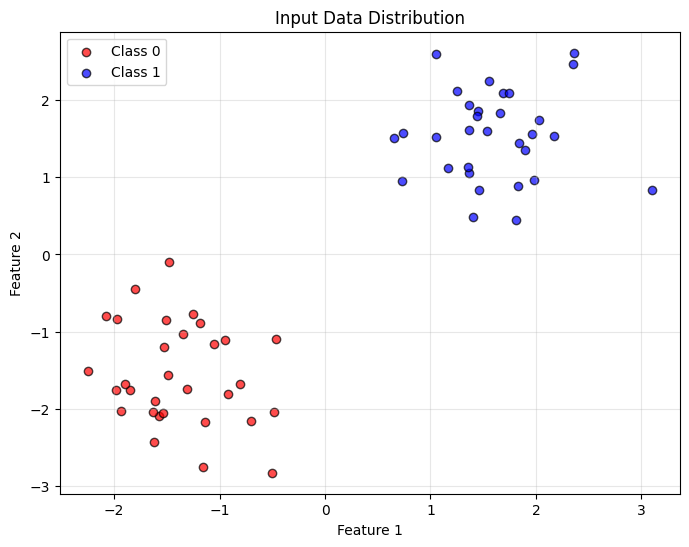

In [3]:
# Visualization of input data
plt.figure(figsize=(8, 6))
plt.scatter(class_zero[:, 0], class_zero[:, 1], c='red', label='Class 0', alpha=0.7, edgecolors='k')
plt.scatter(class_one[:, 0], class_one[:, 1], c='blue', label='Class 1', alpha=0.7, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Input Data Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
class PerceptronClassifier:
    def __init__(self, learning_rate=0.01, iterations=100):
        self.lr = learning_rate
        self.max_iter = iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def fit(self, X_train, y_train):
        # Initialize parameters
        self.weights = np.zeros(X_train.shape[1])
        self.bias = 0.0
        self.loss_history = []
        
        # Training loop
        for iteration in range(self.max_iter):
            errors = 0
            
            for i in range(len(X_train)):
                # Compute prediction
                linear_sum = np.dot(X_train[i], self.weights) + self.bias
                prediction = 1 if linear_sum >= 0 else 0
                y_actual = int(y_train[i])
                
                # Misclassification check
                if prediction != y_actual:
                    # Update weights and bias
                    update_amount = self.lr * (y_actual - prediction)
                    self.weights += update_amount * X_train[i]
                    self.bias += update_amount
                    errors += 1
            
            self.loss_history.append(errors)
        
        return self
    
    def predict(self, X_test):
        linear_output = np.dot(X_test, self.weights) + self.bias
        return (linear_output >= 0).astype(int)

In [5]:
class LogisticRegressionModel:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.max_iter = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
    
    def sigmoid(self, z):
        # Numerically stable sigmoid
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))
    
    def fit(self, X_train, y_train):
        # Initialize parameters
        self.weights = np.zeros(X_train.shape[1])
        self.bias = 0.0
        self.cost_history = []
        m = len(X_train)
        
        # Gradient descent
        for iteration in range(self.max_iter):
            # Forward pass
            z = np.dot(X_train, self.weights) + self.bias
            predictions = self.sigmoid(z)
            
            # Compute cost (binary cross-entropy)
            epsilon = 1e-15
            predictions = np.clip(predictions, epsilon, 1 - epsilon)
            cost = -np.mean(y_train * np.log(predictions) + (1 - y_train) * np.log(1 - predictions))
            self.cost_history.append(cost)
            
            # Backward pass - compute gradients
            dw = (1/m) * np.dot(X_train.T, (predictions - y_train))
            db = (1/m) * np.sum(predictions - y_train)
            
            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
        
        return self
    
    def predict(self, X_test):
        z = np.dot(X_test, self.weights) + self.bias
        probabilities = self.sigmoid(z)
        return (probabilities >= 0.5).astype(int)

In [6]:
# Train Perceptron
perceptron = PerceptronClassifier(learning_rate=0.05, iterations=50)
perceptron.fit(X, y)

# Train Logistic Regression
log_reg = LogisticRegressionModel(learning_rate=0.1, iterations=200)
log_reg.fit(X, y)

print("Models trained successfully!")

Models trained successfully!


In [7]:
# Get predictions from both models
y_pred_perceptron = perceptron.predict(X)
y_pred_logistic = log_reg.predict(X)

# Calculate accuracies
acc_perceptron = accuracy_score(y, y_pred_perceptron)
acc_logistic = accuracy_score(y, y_pred_logistic)

print(f"Perceptron Accuracy: {acc_perceptron:.4f}")
print(f"Logistic Regression Accuracy: {acc_logistic:.4f}")

Perceptron Accuracy: 1.0000
Logistic Regression Accuracy: 1.0000


In [8]:
# Confusion matrices
cm_perceptron = confusion_matrix(y, y_pred_perceptron)
cm_logistic = confusion_matrix(y, y_pred_logistic)

print("Perceptron Confusion Matrix:")
print(cm_perceptron)
print("\nLogistic Regression Confusion Matrix:")
print(cm_logistic)

Perceptron Confusion Matrix:
[[31  0]
 [ 0 31]]

Logistic Regression Confusion Matrix:
[[31  0]
 [ 0 31]]


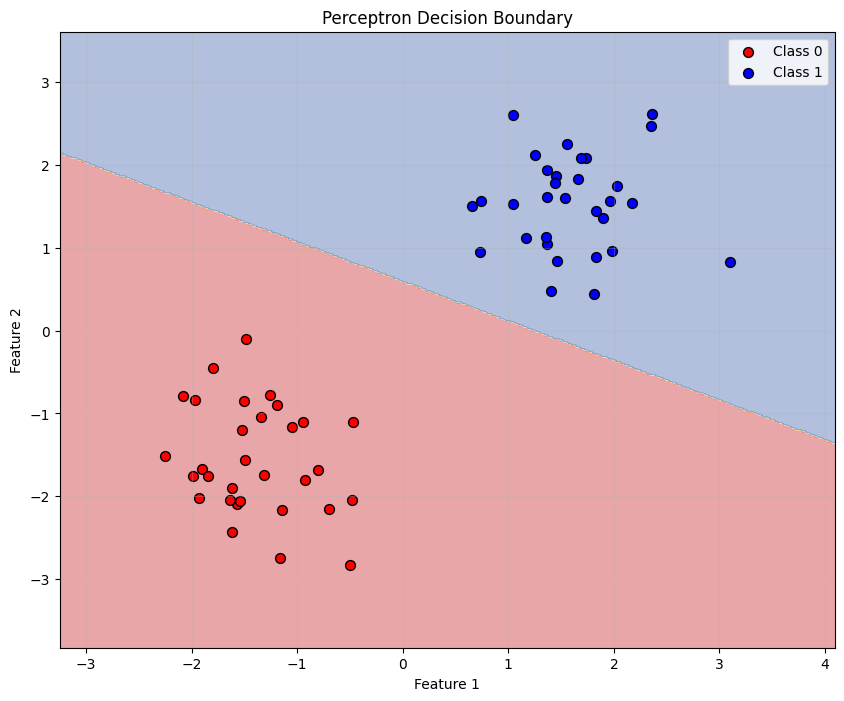

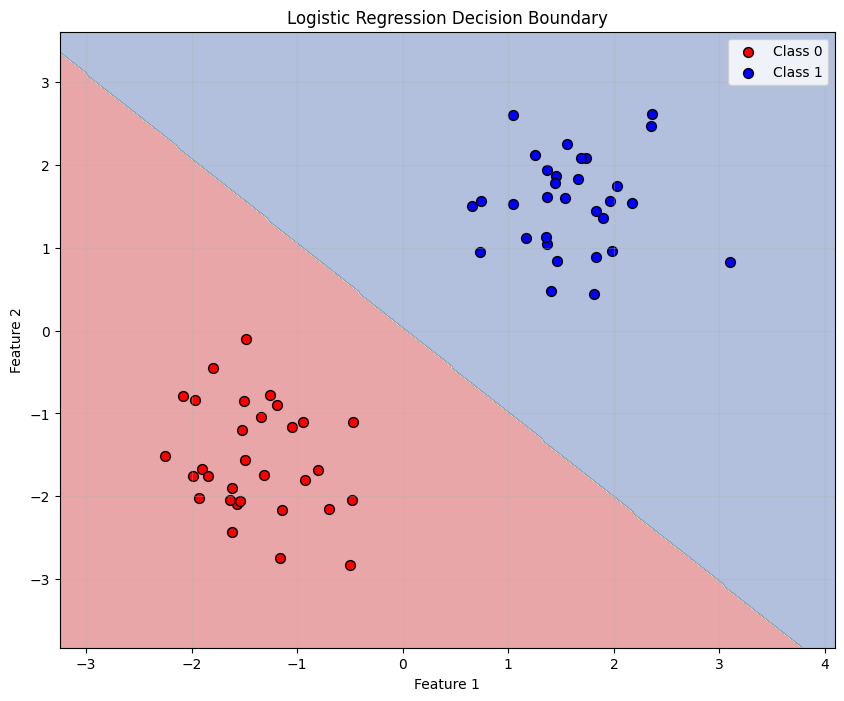

In [9]:
def plot_decision_boundary(X, y, model, title):
    h = 0.02  # step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.4)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', edgecolors='k', s=50)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', edgecolors='k', s=50)
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(X, y, perceptron, 'Perceptron Decision Boundary')
plot_decision_boundary(X, y, log_reg, 'Logistic Regression Decision Boundary')

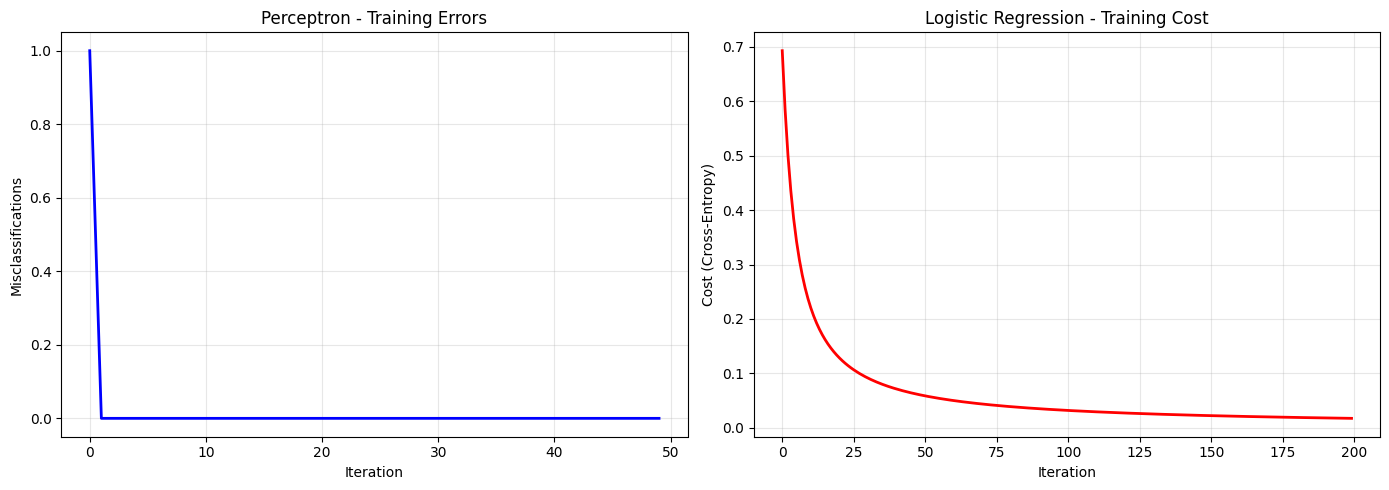

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Perceptron error history
axes[0].plot(perceptron.loss_history, 'b-', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Misclassifications')
axes[0].set_title('Perceptron - Training Errors')
axes[0].grid(True, alpha=0.3)

# Logistic Regression cost history
axes[1].plot(log_reg.cost_history, 'r-', linewidth=2)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost (Cross-Entropy)')
axes[1].set_title('Logistic Regression - Training Cost')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
print("="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
print(f"\nDataset Parameters:")
print(f"  - Total Samples: {total_samples}")
print(f"  - Noise Level: {noise_level}")
print(f"  - Rotation Angle: {np.rad2deg(rotation_angle):.1f} degrees")
print(f"\nPerceptron Performance:")
print(f"  - Accuracy: {acc_perceptron:.4f}")
print(f"  - Final Errors: {perceptron.loss_history[-1]}")
print(f"\nLogistic Regression Performance:")
print(f"  - Accuracy: {acc_logistic:.4f}")
print(f"  - Final Cost: {log_reg.cost_history[-1]:.4f}")
print("="*50)

MODEL COMPARISON SUMMARY

Dataset Parameters:
  - Total Samples: 31
  - Noise Level: 0.15
  - Rotation Angle: 30.0 degrees

Perceptron Performance:
  - Accuracy: 1.0000
  - Final Errors: 0

Logistic Regression Performance:
  - Accuracy: 1.0000
  - Final Cost: 0.0171
